# Image Exploratory Data Analysis (EDA)

This notebook explores the characteristics of real vs. AI-generated images using the CIFAKE dataset. We will compare visual features, color distributions, and frequency domain characteristics to identify potential artifacts in AI-generated content.

## Summary:
### Analysis of RGB Channel Distributions
- **Red & Green Channels**: Real images show a smoother distribution concentrated in the mid-tones. In contrast, AI images exhibit distinct spikes in the high-intensity range (200-250), suggesting artificial oversaturation or "blown-out" highlights.
- **Blue Channel**: This channel shows the most significant divergence. Real images have a much higher density in the deep shadows (0-50), while AI images have a flatter distribution shifted toward the mid-tones and highlights, lacking the deep shadow complexity of natural images.

Key Takeaways

The AI images in this dataset tend to be more "vibrant" but lack the subtle tonal range and shadow depth characteristic of real photography.

### Edge Density Distribution Analysis
The Edge Density Distribution (Sobel Magnitude) reveals a clear distinction between the two classes. Real images (blue) exhibit a broader distribution with a peak around 150 and a significant "long tail" extending into high-magnitude regions (200-300), indicating sharper, more complex high-frequency details. Conversely, AI images (red) show a narrower, more peaked distribution centered lower (around 130), with a sharp drop-off in high-intensity edges. This suggests that AI models tend to produce **_smoother_** images, lacking the extreme sharpness and intricate texture complexity inherent in real-world photography, likely due to generative smoothing effects.

In [16]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm
import torch

# Add the project root to sys.path to import data_loaders
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from image_data_loaders import CIFAKEDataset, ImageSource

print(f"Project root: {project_root}")

Project root: /Users/mahitarashid/work/genai-projects-2025/real_vs_ai_image


## 1. Load Dataset

We'll load a sample of the CIFAKE dataset (which consists of CIFAR-10 real images and Stable Diffusion generated images).

In [17]:
# Load a subset for EDA
dataset = CIFAKEDataset(
    split="train",
    transform=None,  # We want raw images for EDA
    max_samples=10000
)

real_samples = [s for s in dataset.samples if s["label"] == 0]
fake_samples = [s for s in dataset.samples if s["label"] == 1]

print(f"Loaded {len(real_samples)} real and {len(fake_samples)} fake samples.")

Loading CIFAKE train split...
[train] got 100,000 samples
Loaded 10000 samples
  Real: 4902, AI: 5098
Loaded 4902 real and 5098 fake samples.


## 2. Visual Comparison

Let's look at random samples from both classes.

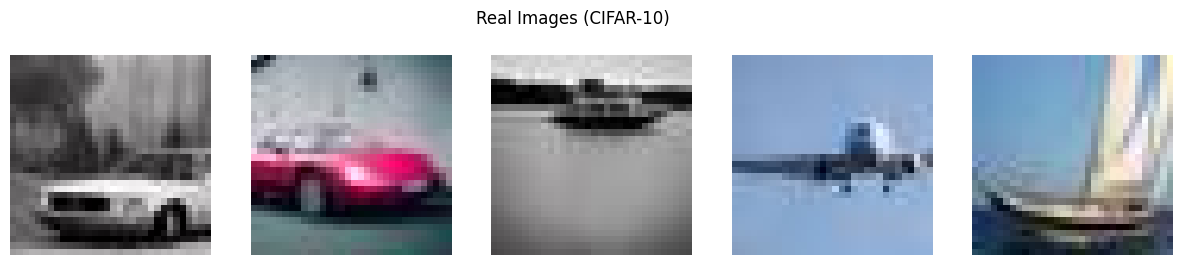

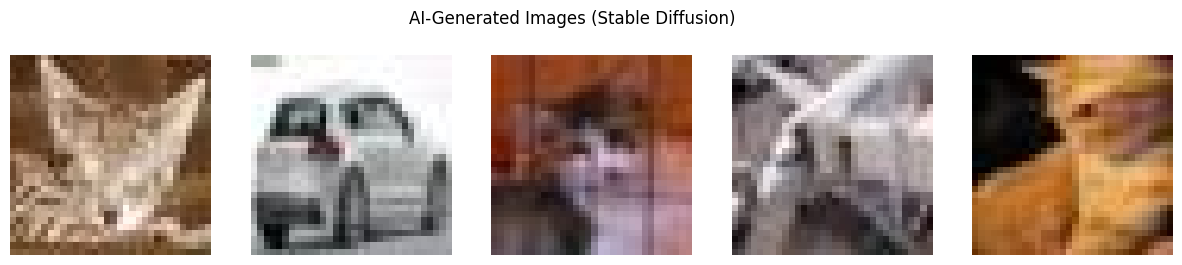

In [19]:
def plot_samples(samples, title, n=5):
    plt.figure(figsize=(15, 3))
    indices = random.sample(range(len(samples)), n)
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(samples[idx]["image_data"])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

plot_samples(real_samples, "Real Images (CIFAR-10)")
plot_samples(fake_samples, "AI-Generated Images (Stable Diffusion)")

## 3. Color Distribution Analysis

Analyzing the RGB channel histograms and brightness distributions.

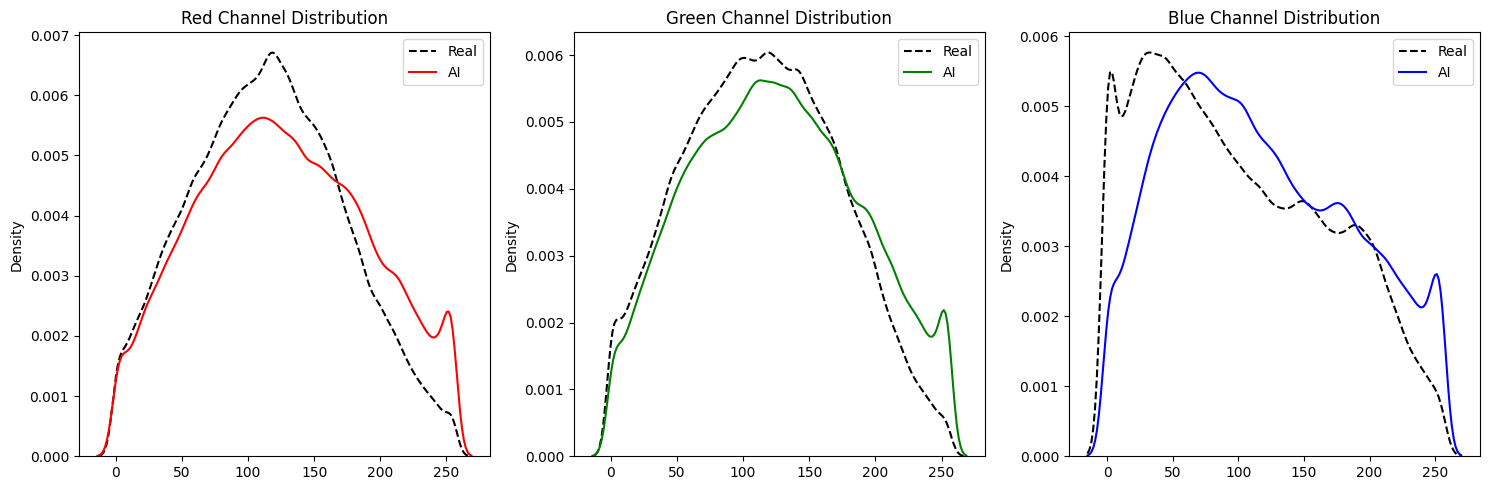

In [20]:
def get_color_stats(samples):
    all_pixels = []
    for s in samples[:500]: # Sample 500 for speed
        img = np.array(s["image_data"])
        all_pixels.append(img.reshape(-1, 3))
    return np.concatenate(all_pixels, axis=0)

real_pixels = get_color_stats(real_samples)
fake_pixels = get_color_stats(fake_samples)

colors = ['red', 'green', 'blue']
plt.figure(figsize=(15, 5))
for i, color in enumerate(colors):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(real_pixels[:, i], color='black', label='Real', linestyle='--')
    sns.kdeplot(fake_pixels[:, i], color=color, label='AI')
    plt.title(f'{color.capitalize()} Channel Distribution')
    plt.legend()
plt.tight_layout()
plt.show()

## 4. Edge Density Analysis

AI images often have different sharpness or texture patterns. We use the Sobel operator to analyze edge density.

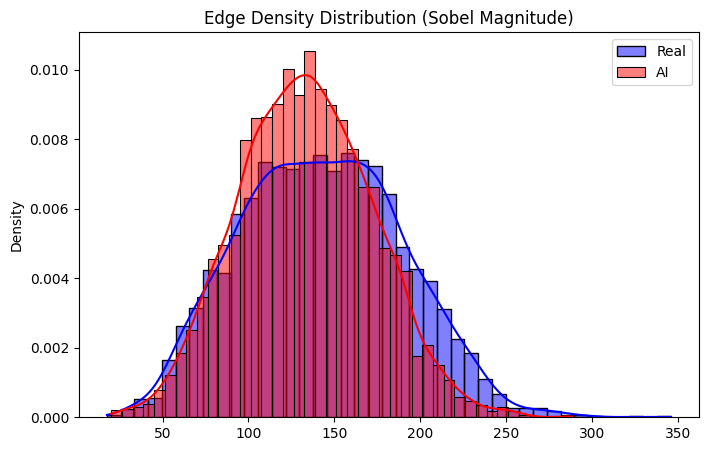

In [21]:
def calculate_edge_density(samples):
    densities = []
    for s in samples:
        img = np.array(s["image_data"].convert("L"))
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sobelx**2 + sobely**2)
        densities.append(np.mean(mag))
    return densities

real_edges = calculate_edge_density(real_samples)
fake_edges = calculate_edge_density(fake_samples)

plt.figure(figsize=(8, 5))
sns.histplot(real_edges, color="blue", label="Real", kde=True, stat="density")
sns.histplot(fake_edges, color="red", label="AI", kde=True, stat="density")
plt.title("Edge Density Distribution (Sobel Magnitude)")
plt.legend()
plt.show()

## 5. Frequency Domain Analysis (FFT)

Generative models often leave "checkerboard" artifacts in the frequency domain due to upsampling layers (e.g., transposed convolutions).

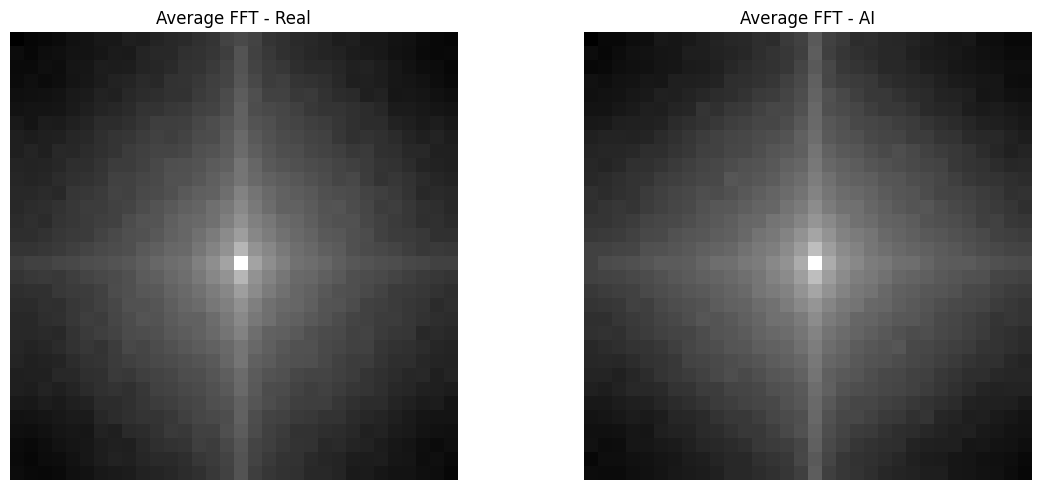

In [23]:
def get_average_fft(samples, n=100):
    fft_sum = None
    for i in range(min(n, len(samples))):
        img = np.array(samples[i]["image_data"].convert("L"))
        f = np.fft.fft2(img)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
        
        if fft_sum is None:
            fft_sum = magnitude_spectrum
        else:
            fft_sum += magnitude_spectrum
    return fft_sum / n

real_fft = get_average_fft(real_samples)
fake_fft = get_average_fft(fake_samples)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(real_fft, cmap='gray')
plt.title("Average FFT - Real")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(fake_fft, cmap='gray')
plt.title("Average FFT - AI")
plt.axis("off")

plt.tight_layout()
plt.show()